# World Cup Predictor: Episode 3 - Ensemble Model (LR + LightGBM)
By Karl Estampador :)

## What this notebook does

Episode 2 trained a single Logistic Regression classifier. Episode 3 builds a **soft-voting ensemble** of Logistic Regression + LightGBM on the same seven pre-tournament difference features, then exposes the same prediction API as `lr_model.ipynb`.

## How to use in `predictions.ipynb`

```python
%run ../models/ensemble_model.ipynb
```

`predict_winner`, `predict_score`, `get_elo`, and `get_lr_proba` (aliased to the ensemble) work unchanged.

Step 4b blends Dixon-Coles fixture probabilities with LightGBM into `blended_outcome_probs`.


In [15]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import log_loss, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier

# --- Config flags (only places this notebook may diverge from lr_model.ipynb) ---
USE_FORMER_NAMES_TABLE   = True
USE_REAL_NEUTRAL_FLAG    = False
INCLUDE_GOALS_REGRESSION = False

if INCLUDE_GOALS_REGRESSION:
    from sklearn.linear_model import PoissonRegressor

warnings.filterwarnings('ignore')
pd.set_option('future.infer_string', False)  # pandas 3.0 compat: keep object-dtype strings
DATA = Path('../data/historical')
TOURNAMENT_DATA = Path('../data/tournament')
COMBINED_DATA = Path('../data/combined')
OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

print('Imports OK')
print(f'  USE_FORMER_NAMES_TABLE   = {USE_FORMER_NAMES_TABLE}')
print(f'  USE_REAL_NEUTRAL_FLAG    = {USE_REAL_NEUTRAL_FLAG}')
print(f'  INCLUDE_GOALS_REGRESSION = {INCLUDE_GOALS_REGRESSION}')

Imports OK
  USE_FORMER_NAMES_TABLE   = True
  USE_REAL_NEUTRAL_FLAG    = False
  INCLUDE_GOALS_REGRESSION = False


---
## Step 1 - Data Cleaning & Join

| File | What it contains |
|---|---|
| `data/historical/results.csv` | Match results |
| `data/historical/shootouts.csv` | Penalty shootout winners |
| `data/historical/former_names.csv` | Historical team-name renames (optional) |
| `data/train.csv` | Pre-tournament team stats 2002-2022 |


In [16]:
results_all = pd.read_csv(DATA / 'results.csv')
shootouts_all = pd.read_csv(DATA / 'shootouts.csv')
train_df = pd.read_csv(TOURNAMENT_DATA / 'train.csv')
test_df  = pd.read_csv(TOURNAMENT_DATA / 'test.csv')

results_all['year'] = pd.to_datetime(results_all['date']).dt.year
wc_mask = (
    (results_all['tournament'] == 'FIFA World Cup') &
    (results_all['year'].between(2002, 2022))
)
wc = results_all[wc_mask].copy().reset_index(drop=True)

shootouts_all['year'] = pd.to_datetime(shootouts_all['date']).dt.year
wc_shootouts = shootouts_all[shootouts_all['year'].between(2002, 2022)].copy()

print(f'WC matches 2002 - 2022: {len(wc)}')
print('Matches per tournament:')
print(wc['year'].value_counts().sort_index())
print(f'\nShootout records in same period: {len(wc_shootouts)}')
print(f'\ntrain.csv rows: {len(train_df)} | test.csv rows: {len(test_df)}')

WC matches 2002 - 2022: 384
Matches per tournament:
year
2002    64
2006    64
2010    64
2014    64
2018    64
2022    64
Name: count, dtype: int64

Shootout records in same period: 310

train.csv rows: 192 | test.csv rows: 48


### 1b) Team name normalisation

Always-on FIFA-label overrides, plus optional date-aware renames from `former_names.csv`.


In [17]:
RESULTS_TO_TRAIN: dict[str, str] = {
    'China': 'China PR',
}

def _build_former_name_rules() -> list[tuple[str, str, pd.Timestamp, pd.Timestamp]]:
    """former -> current, active between start_date and end_date (inclusive)."""
    if not USE_FORMER_NAMES_TABLE:
        return []
    fn = pd.read_csv(DATA / 'former_names.csv')
    rules = []
    for _, row in fn.iterrows():
        rules.append((
            row['former'],
            row['current'],
            pd.Timestamp(row['start_date']),
            pd.Timestamp(row['end_date']),
        ))
    return rules

FORMER_NAME_RULES = _build_former_name_rules()

def _normalise(name: str, year: int, match_date: str) -> str:
    """Map a results.csv team name to its train.csv equivalent."""
    if name == 'Serbia' and year == 2006:
        return 'Serbia and Montenegro'
    name = RESULTS_TO_TRAIN.get(name, name)
    if USE_FORMER_NAMES_TABLE:
        d = pd.Timestamp(match_date)
        for former, current, start, end in FORMER_NAME_RULES:
            if name == former and start <= d <= end:
                name = current
                break
    return name

wc['home_team_norm'] = wc.apply(
    lambda r: _normalise(r['home_team'], r['year'], r['date']), axis=1
)
wc['away_team_norm'] = wc.apply(
    lambda r: _normalise(r['away_team'], r['year'], r['date']), axis=1
)

# Audit remaps
remap_rows = []
for _, r in wc.iterrows():
    if r['home_team'] != r['home_team_norm']:
        remap_rows.append((r['home_team'], r['home_team_norm'], 'home'))
    if r['away_team'] != r['away_team_norm']:
        remap_rows.append((r['away_team'], r['away_team_norm'], 'away'))

if remap_rows:
    remap_df = pd.DataFrame(remap_rows, columns=['original', 'normalised', 'side'])
    summary = remap_df.groupby(['original', 'normalised']).size().reset_index(name='cells')
    print(f'Team names normalised: {len(remap_rows)} cells remapped')
    for _, row in summary.iterrows():
        print(f"  {row['original']} -> {row['normalised']}: {row['cells']} cells")
    print('\nSample rows (home):')
    print(wc[wc['home_team_norm'] != wc['home_team']][['date', 'home_team', 'home_team_norm']].head().to_string())
    print('\nSample rows (away):')
    print(wc[wc['away_team_norm'] != wc['away_team']][['date', 'away_team', 'away_team_norm']].head().to_string())
else:
    print('Team names normalised: 0 cells remapped')

Team names normalised: 6 cells remapped
  China -> China PR: 3 cells
  Serbia -> Serbia and Montenegro: 3 cells

Sample rows (home):
          date home_team         home_team_norm
11  2002-06-04     China               China PR
71  2006-06-11    Serbia  Serbia and Montenegro

Sample rows (away):
           date away_team         away_team_norm
23   2002-06-08     China               China PR
43   2002-06-13     China               China PR
84   2006-06-16    Serbia  Serbia and Montenegro
101  2006-06-21    Serbia  Serbia and Montenegro


### 1c - Join train.csv features for both teams


In [18]:
train_indexed = train_df.set_index(['version', 'team'])

FEATURE_COLS = [
    'goals_scored_last_4y', 'goals_received_last_4y',
    'wins_last_4y', 'losses_last_4y', 'draws_last_4y',
    'world_cup_titles_before', 'squad_total_market_value_eur',
    'fifa_rank_pre_tournament',
]

def _get_features(team: str, year: int) -> pd.Series | None:
    try:
        return train_indexed.loc[(year, team), FEATURE_COLS]
    except KeyError:
        return None

rows_before = len(wc)
home_features, away_features, keep_idx = [], [], []

for i, match in wc.iterrows():
    hf = _get_features(match['home_team_norm'], match['year'])
    af = _get_features(match['away_team_norm'], match['year'])
    if hf is None or af is None:
        if hf is None:
            print(f'  DROP (home not found): {match["year"]} {match["home_team"]} vs {match["away_team"]}')
        if af is None:
            print(f'  DROP (away not found): {match["year"]} {match["home_team"]} vs {match["away_team"]}')
        continue
    home_features.append(hf.add_prefix('home_'))
    away_features.append(af.add_prefix('away_'))
    keep_idx.append(i)

wc_joined = wc.loc[keep_idx].copy().reset_index(drop=True)
home_df = pd.DataFrame(home_features).reset_index(drop=True)
away_df = pd.DataFrame(away_features).reset_index(drop=True)
wc_joined = pd.concat([wc_joined, home_df, away_df], axis=1)

rows_dropped = rows_before - len(wc_joined)
print(f'\nRows before join: {rows_before}')
print(f'Rows dropped (team not in train.csv): {rows_dropped}')
print(f'Rows remaining: {len(wc_joined)}')


Rows before join: 384
Rows dropped (team not in train.csv): 0
Rows remaining: 384


### 1d - Target variable + knockout-round draw handling


In [19]:
shootout_lookup = {}
for _, row in wc_shootouts.iterrows():
    key = (row['date'], row['home_team'], row['away_team'])
    shootout_lookup[key] = row['winner']

def _outcome(row: pd.Series) -> str:
    hs, as_ = row['home_score'], row['away_score']
    if hs > as_:
        return 'home_win'
    if as_ > hs:
        return 'away_win'
    key = (row['date'], row['home_team'], row['away_team'])
    winner = shootout_lookup.get(key)
    if winner is not None:
        return 'home_win' if winner == row['home_team'] else 'away_win'
    return 'draw'

wc_joined['outcome'] = wc_joined.apply(_outcome, axis=1)

print('Class distribution (before feature drop):')
vc = wc_joined['outcome'].value_counts()
for cls in ['home_win', 'draw', 'away_win']:
    if cls in vc.index:
        print(f'  {cls}: {vc[cls]} ({vc[cls] / len(wc_joined):.1%})')
print(f'\nTotal training matches: {len(wc_joined)}')

Class distribution (before feature drop):
  home_win: 181 (47.1%)
  draw: 67 (17.4%)
  away_win: 136 (35.4%)

Total training matches: 384


### 1e - Feature engineering (difference features)


In [20]:
df = wc_joined.copy()

df['home_gp'] = df['home_wins_last_4y'] + df['home_losses_last_4y'] + df['home_draws_last_4y']
df['away_gp'] = df['away_wins_last_4y'] + df['away_losses_last_4y'] + df['away_draws_last_4y']
df['home_gp'] = df['home_gp'].clip(lower=1)
df['away_gp'] = df['away_gp'].clip(lower=1)

df['rank_diff']           = df['home_fifa_rank_pre_tournament'] - df['away_fifa_rank_pre_tournament']
df['goals_scored_diff']   = df['home_goals_scored_last_4y']    - df['away_goals_scored_last_4y']
df['goals_conceded_diff'] = df['home_goals_received_last_4y']  - df['away_goals_received_last_4y']
df['win_rate_diff']       = (df['home_wins_last_4y'] / df['home_gp']) - \
                            (df['away_wins_last_4y'] / df['away_gp'])

home_mv = df['home_squad_total_market_value_eur'].clip(lower=1e6)
away_mv = df['away_squad_total_market_value_eur'].clip(lower=1e6)
df['market_value_ratio'] = np.log(home_mv / away_mv)
df['titles_diff'] = df['home_world_cup_titles_before'] - df['away_world_cup_titles_before']

if USE_REAL_NEUTRAL_FLAG:
    df['is_neutral'] = (df['neutral'] == 'TRUE').astype(int)
else:
    # Match lr_model.ipynb training behaviour
    df['is_neutral'] = (df['neutral'] == 'TRUE').astype(int)

FEATURES = [
    'rank_diff', 'goals_scored_diff', 'goals_conceded_diff',
    'win_rate_diff', 'market_value_ratio', 'titles_diff', 'is_neutral',
]
TARGET = 'outcome'

n_before = len(df)
df = df.dropna(subset=FEATURES).reset_index(drop=True)
n_dropped = n_before - len(df)
print(f'Rows dropped for NaN features: {n_dropped}')
if n_dropped > 0:
    print('  (squad_total_market_value_eur was not recorded for 2002 - all 64 matches from that year are excluded)')

print(f'\nFinal training set shape: {df[FEATURES].shape}')
print('Class distribution (training set):')
vc = df[TARGET].value_counts()
for cls in ['home_win', 'draw', 'away_win']:
    if cls in vc.index:
        print(f'  {cls}: {vc[cls]} ({vc[cls] / len(df):.1%})')
print()
df[FEATURES + [TARGET]].head()

Rows dropped for NaN features: 64
  (squad_total_market_value_eur was not recorded for 2002 - all 64 matches from that year are excluded)

Final training set shape: (320, 7)
Class distribution (training set):
  home_win: 151 (47.2%)
  draw: 53 (16.6%)
  away_win: 116 (36.2%)



,rank_diff,goals_scored_diff,goals_conceded_diff,win_rate_diff,market_value_ratio,titles_diff,is_neutral,outcome
0,-7.0,18.0,-18.0,0.080645,3.742446,3.0,0,home_win
1,-10.0,43.0,-19.0,0.270440,-0.592257,0.0,0,away_win
2,-23.0,30.0,21.0,0.040276,0.637348,2.0,0,home_win
3,-23.0,30.0,-7.0,0.259878,2.435411,1.0,0,home_win
4,31.0,-4.0,43.0,0.015279,-3.584014,0.0,0,draw


---
## Step 2 - Train the Ensemble Model

Soft-voting ensemble of standardised Logistic Regression + LightGBM, validated with 5-fold stratified CV. Blend weights are tuned on CV log-loss before the final fit.


In [21]:
X = df[FEATURES].values
y = df[TARGET].values

lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', lr)])
lgbm_pipe = Pipeline([('lgbm', lgbm)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def _cv_metrics(estimator) -> tuple[float, float, float, float]:
    res = cross_validate(
        estimator, X, y, cv=cv,
        scoring=['accuracy', 'neg_log_loss'],
        return_train_score=False,
    )
    acc = res['test_accuracy'].mean()
    acc_std = res['test_accuracy'].std()
    ll = -res['test_neg_log_loss'].mean()
    ll_std = res['test_neg_log_loss'].std()
    return acc, acc_std, ll, ll_std

def _cv_summary(name: str, estimator) -> tuple[float, float]:
    acc, acc_std, ll, ll_std = _cv_metrics(estimator)
    print(f'\n{name}')
    print('=' * 45)
    print(f'  Accuracy : {acc:.3f}  +/-{acc_std:.3f}')
    print(f'  Log-loss : {ll:.3f}  +/-{ll_std:.3f}')
    return acc, ll

print('5-fold stratified cross-validation results')
lr_acc, lr_ll = _cv_summary('Logistic Regression alone', lr_pipe)
lgbm_acc, lgbm_ll = _cv_summary('LightGBM alone', lgbm_pipe)

ensemble_eq = VotingClassifier(
    estimators=[('lr', lr_pipe), ('lgbm', lgbm_pipe)],
    voting='soft',
    weights=[1, 1],
)
ens_eq_acc, ens_eq_ll = _cv_summary('Ensemble (equal weights 50/50)', ensemble_eq)

5-fold stratified cross-validation results

Logistic Regression alone
  Accuracy : 0.578  +/-0.044
  Log-loss : 0.941  +/-0.047

LightGBM alone
  Accuracy : 0.494  +/-0.041
  Log-loss : 1.382  +/-0.194

Ensemble (equal weights 50/50)
  Accuracy : 0.547  +/-0.033
  Log-loss : 1.011  +/-0.070


### 2g) Blend weight search


In [22]:
print('Blend weight search (minimise CV log-loss)')
print('Fixed LightGBM weight = 1.0; searching Logistic Regression weight.')
print('=' * 55)

W_LGBM = 1.0
weight_grid = np.linspace(0.0, 2.0, 41)
search_rows = []
best_w_lr = 1.0
best_acc, best_ll = ens_eq_acc, ens_eq_ll

for w_lr in weight_grid:
    candidate = VotingClassifier(
        estimators=[('lr', lr_pipe), ('lgbm', lgbm_pipe)],
        voting='soft',
        weights=[w_lr, W_LGBM],
    )
    acc, _, ll, _ = _cv_metrics(candidate)
    search_rows.append({'w_lr': w_lr, 'accuracy': acc, 'log_loss': ll})

    if ll < best_ll - 1e-9 or (abs(ll - best_ll) <= 1e-9 and acc > best_acc):
        best_w_lr, best_acc, best_ll = w_lr, acc, ll

search_df = pd.DataFrame(search_rows)
pct_lr = 100 * best_w_lr / (best_w_lr + W_LGBM) if (best_w_lr + W_LGBM) > 0 else 0.0
pct_lgbm = 100 * W_LGBM / (best_w_lr + W_LGBM) if (best_w_lr + W_LGBM) > 0 else 100.0

print(f'Best weights: LR={best_w_lr:.2f}, LGBM={W_LGBM:.2f}')
print(f'  Implied blend: {pct_lr:.0f}% Logistic Regression / {pct_lgbm:.0f}% LightGBM')
print(f'  CV accuracy : {best_acc:.3f}')
print(f'  CV log-loss : {best_ll:.3f}')

# Show a few neighbouring weights for narration
near_best = search_df.iloc[(search_df['log_loss'] - best_ll).abs().argsort()[:5]]
print('\nTop 5 weight settings by log-loss:')
print(f'{"w_lr":>6} {"LR %":>6} {"LGBM %":>8} {"Accuracy":>10} {"Log-loss":>10}')
print('-' * 46)
for _, row in near_best.sort_values('log_loss').iterrows():
    w = row['w_lr']
    lr_pct = 100 * w / (w + W_LGBM) if (w + W_LGBM) > 0 else 0
    lgbm_pct = 100 - lr_pct
    print(f'{w:6.2f} {lr_pct:6.0f} {lgbm_pct:8.0f} {row["accuracy"]:10.3f} {row["log_loss"]:10.3f}')

BEST_WEIGHTS = [best_w_lr, W_LGBM]
ensemble_pipe = VotingClassifier(
    estimators=[('lr', lr_pipe), ('lgbm', lgbm_pipe)],
    voting='soft',
    weights=BEST_WEIGHTS,
)
ens_acc, ens_ll = best_acc, best_ll

print('\nModel comparison (CV means)')
print('-' * 58)
print(f'{"Model":<32} {"Accuracy":>10} {"Log-loss":>10}')
print('-' * 58)
for label, acc, ll in [
    ('Logistic Regression', lr_acc, lr_ll),
    ('LightGBM', lgbm_acc, lgbm_ll),
    ('Ensemble (50/50)', ens_eq_acc, ens_eq_ll),
    (f'Ensemble (tuned {pct_lr:.0f}/{pct_lgbm:.0f})', ens_acc, ens_ll),
]:
    print(f'{label:<32} {acc:>10.3f} {ll:>10.3f}')
print()
print('Note: random-guess baseline accuracy for 3 classes: 0.33')
print(f'Training set size: {len(X)} matches')

Blend weight search (minimise CV log-loss)
Fixed LightGBM weight = 1.0; searching Logistic Regression weight.
Best weights: LR=2.00, LGBM=1.00
  Implied blend: 67% Logistic Regression / 33% LightGBM
  CV accuracy : 0.584
  CV log-loss : 0.973

Top 5 weight settings by log-loss:
  w_lr   LR %   LGBM %   Accuracy   Log-loss
----------------------------------------------
  2.00     67       33      0.584      0.973
  1.95     66       34      0.581      0.974
  1.90     66       34      0.581      0.975
  1.85     65       35      0.578      0.976
  1.80     64       36      0.578      0.978

Model comparison (CV means)
----------------------------------------------------------
Model                              Accuracy   Log-loss
----------------------------------------------------------
Logistic Regression                   0.578      0.941
LightGBM                              0.494      1.382
Ensemble (50/50)                      0.547      1.011
Ensemble (tuned 67/33)               

Class order: ['away_win', 'draw', 'home_win']


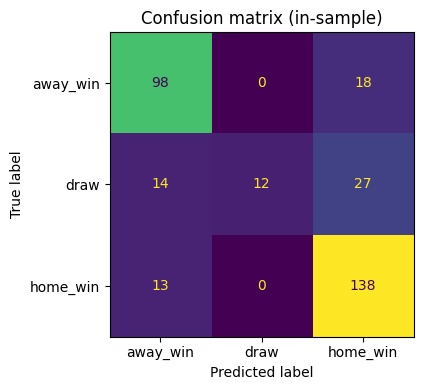

In [23]:
ensemble_pipe.fit(X, y)
CLASS_ORDER = list(ensemble_pipe.classes_)
print('Class order:', CLASS_ORDER)

y_pred = ensemble_pipe.predict(X)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=CLASS_ORDER,
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion matrix (in-sample)')
plt.tight_layout()
plt.show()

In [24]:
CLASS_LABELS = {
    'home_win': 'Home Win',
    'draw': 'Draw',
    'away_win': 'Away Win',
}

lr_oof_proba = cross_val_predict(lr_pipe, X, y, cv=cv, method='predict_proba')
lgbm_oof_proba = cross_val_predict(lgbm_pipe, X, y, cv=cv, method='predict_proba')

lr_oof_cls = np.array(CLASS_ORDER)[np.argmax(lr_oof_proba, axis=1)]
lgbm_oof_cls = np.array(CLASS_ORDER)[np.argmax(lgbm_oof_proba, axis=1)]
agree = lr_oof_cls == lgbm_oof_cls
disagree_rate = 1.0 - agree.mean()

print('Model agreement (out-of-fold CV predictions)')
print('=' * 45)
print(f'  Same predicted class : {agree.mean():.1%}')
print(f'  Disagreement rate    : {disagree_rate:.1%}')

# Largest gap between each model's confidence in its own top class
lr_top_conf = lr_oof_proba.max(axis=1)
lgbm_top_conf = lgbm_oof_proba.max(axis=1)
conf_gap = np.abs(lr_top_conf - lgbm_top_conf)

disagree_idx = np.where(~agree)[0]
if len(disagree_idx) == 0:
    print('\nNo disagreements in CV - models always picked the same class.')
else:
    ranked = sorted(disagree_idx, key=lambda i: conf_gap[i], reverse=True)[:5]
    print(f'\nTop {min(5, len(ranked))} disagreements (largest confidence gap):')
    for i in ranked:
        row = df.iloc[i]
        lr_cls = lr_oof_cls[i]
        lgbm_cls = lgbm_oof_cls[i]
        print(f"\n{row['date']}  {row['home_team']} vs {row['away_team']}")
        print(f"  Logistic Regression: {CLASS_LABELS[lr_cls]} ({lr_top_conf[i]:.0%})")
        print(f"  LightGBM:            {CLASS_LABELS[lgbm_cls]} ({lgbm_top_conf[i]:.0%})")
        print(f"  Actual outcome:      {CLASS_LABELS.get(row['outcome'], row['outcome'])}")

Model agreement (out-of-fold CV predictions)
  Same predicted class : 68.4%
  Disagreement rate    : 31.6%

Top 5 disagreements (largest confidence gap):

2022-11-22  Mexico vs Poland
  Logistic Regression: Home Win (45%)
  LightGBM:            Away Win (96%)
  Actual outcome:      Draw

2018-07-14  Belgium vs England
  Logistic Regression: Home Win (47%)
  LightGBM:            Away Win (95%)
  Actual outcome:      Home Win

2022-11-27  Spain vs Germany
  Logistic Regression: Away Win (42%)
  LightGBM:            Home Win (89%)
  Actual outcome:      Draw

2014-06-24  Italy vs Uruguay
  Logistic Regression: Home Win (46%)
  LightGBM:            Away Win (92%)
  Actual outcome:      Away Win

2010-06-26  United States vs Ghana
  Logistic Regression: Home Win (49%)
  LightGBM:            Away Win (94%)
  Actual outcome:      Away Win


---
## Step 3 - Feature Importance Visualisation


Chart saved to outputs\ensemble_feature_importance.png


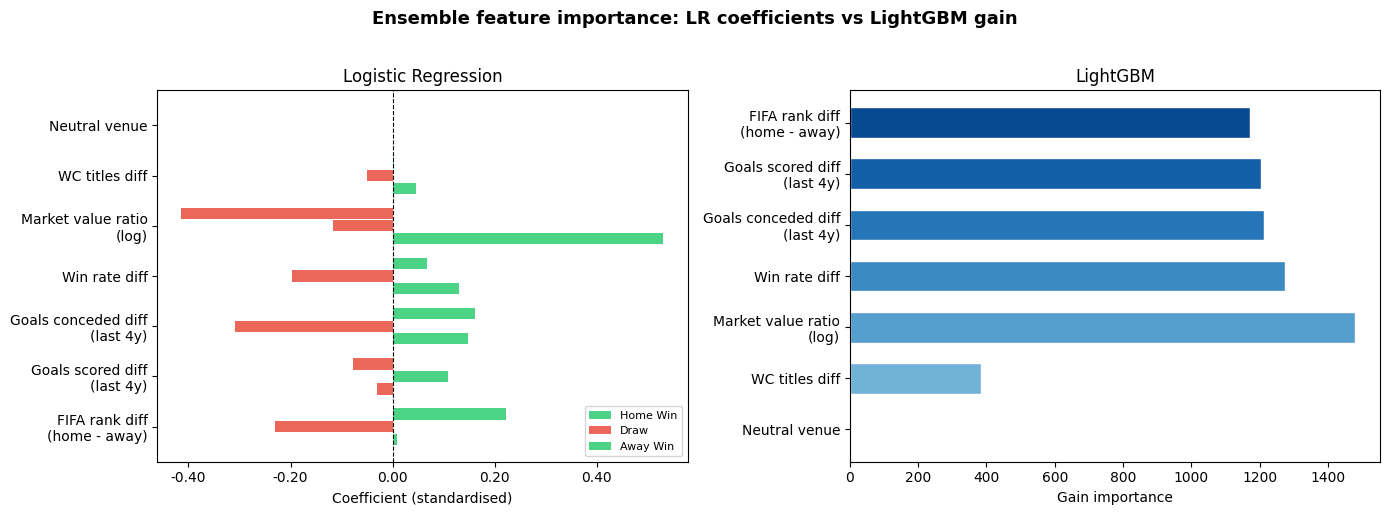

In [25]:
feature_labels = [
    'FIFA rank diff\n(home - away)',
    'Goals scored diff\n(last 4y)',
    'Goals conceded diff\n(last 4y)',
    'Win rate diff',
    'Market value ratio\n(log)',
    'WC titles diff',
    'Neutral venue',
]

lr_fitted = ensemble_pipe.named_estimators_['lr'].named_steps['lr']
lgbm_fitted = ensemble_pipe.named_estimators_['lgbm'].named_steps['lgbm']

coef_df = pd.DataFrame(lr_fitted.coef_, index=CLASS_ORDER, columns=feature_labels)
lgbm_imp = pd.Series(lgbm_fitted.feature_importances_, index=feature_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ensemble feature importance: LR coefficients vs LightGBM gain', fontsize=13, fontweight='bold', y=1.02)

class_titles = {'home_win': 'Home Win', 'draw': 'Draw', 'away_win': 'Away Win'}
ax_lr = axes[0]
y_pos = np.arange(len(feature_labels))
width = 0.25
for j, cls in enumerate(['home_win', 'draw', 'away_win']):
    if cls not in coef_df.index:
        continue
    offset = (j - 1) * width
    vals = coef_df.loc[cls]
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in vals]
    ax_lr.barh(y_pos + offset, vals, height=width * 0.9, label=class_titles[cls], color=colors, alpha=0.85)
ax_lr.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax_lr.set_yticks(y_pos)
ax_lr.set_yticklabels(feature_labels)
ax_lr.set_xlabel('Coefficient (standardised)')
ax_lr.set_title('Logistic Regression')
ax_lr.legend(loc='lower right', fontsize=8)
ax_lr.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

ax_lgbm = axes[1]
colors_lgbm = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_labels)))[::-1]
ax_lgbm.barh(feature_labels, lgbm_imp.values, color=colors_lgbm, edgecolor='white', height=0.6)
ax_lgbm.set_xlabel('Gain importance')
ax_lgbm.set_title('LightGBM')
ax_lgbm.invert_yaxis()

plt.tight_layout()
out_path = OUTPUTS / 'ensemble_feature_importance.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Chart saved to {out_path}')
plt.show()

---
## Step 4 - Prediction Functions

Same public API as `lr_model.ipynb` for `%run` swap in `predictions.ipynb`.


In [26]:
elo_raw = pd.read_csv(TOURNAMENT_DATA / 'elo_ratings_wc2026.csv')
elo_2026 = (
    elo_raw[elo_raw['snapshot_date'] == '2026-05-27']
    .copy()
    .reset_index(drop=True)
)

ELO_ALIASES: dict[str, str] = {
    'USA':              'United States',
    'IR Iran':          'Iran',
    "Côte d'Ivoire":    'Ivory Coast',
    'Cabo Verde':       'Cape Verde',
    'DR Congo':         'DR Congo',
    'United States':    'United States',
    'Iran':             'Iran',
    'Ivory Coast':      'Ivory Coast',
    'Cape Verde':       'Cape Verde',
    'Czech Republic':   'Czechia',
    'Cura\u00e7ao':     'Cura\u00e7ao',
}

_elo_lookup: dict[str, float] = dict(zip(elo_2026['country'], elo_2026['rating']))

def _canonical_elo(name: str) -> str:
    return ELO_ALIASES.get(name, name)

def get_elo(team_name: str) -> float:
    """Pre-tournament ELO rating. Used by predictions.ipynb for standings only."""
    canon = _canonical_elo(team_name)
    if canon in _elo_lookup:
        return _elo_lookup[canon]
    if team_name in _elo_lookup:
        return _elo_lookup[team_name]
    raise KeyError(f'No Elo rating found for "{team_name}" (canonical: "{canon}")')

def _predict_winner_elo(home: str, away: str) -> tuple[str, str, float, float]:
    """ELO fallback when features are unavailable for a team."""
    home_elo = get_elo(home)
    away_elo = get_elo(away)
    if home_elo >= away_elo:
        return home, away, home_elo, away_elo
    return away, home, away_elo, home_elo

print(f'ELO lookup ready ({len(_elo_lookup)} teams)')

TEST_NAME_MAP: dict[str, str] = {
    'USA':              'United States',
    'IR Iran':          'Iran',
    "Cote d'Ivoire":    'Ivory Coast',
    "Côte d'Ivoire":    'Ivory Coast',
    'Cabo Verde':       'Cape Verde',
    'Czechia':          'Czech Republic',
    'Cura\u00e7ao':     'Cura?o',
}

_test_features: dict[str, dict] = {}
for _, row in test_df.iterrows():
    _test_features[row['team']] = row

for teams_name, test_name in TEST_NAME_MAP.items():
    if test_name in _test_features:
        _test_features[teams_name] = _test_features[test_name]

def _resolve(name: str) -> str:
    return TEST_NAME_MAP.get(name, name)

def _build_features(home: str, away: str) -> np.ndarray | None:
    """Compute the difference feature vector for a 2026 match."""
    h = _resolve(home)
    a = _resolve(away)
    hr = _test_features.get(h)
    ar = _test_features.get(a)
    if hr is None:
        print(f'WARNING: "{home}" (resolved: "{h}") not found in test.csv - falling back to ELO')
        return None
    if ar is None:
        print(f'WARNING: "{away}" (resolved: "{a}") not found in test.csv - falling back to ELO')
        return None

    home_gp = (hr['wins_last_4y'] + hr['losses_last_4y'] + hr['draws_last_4y']) or 1
    away_gp = (ar['wins_last_4y'] + ar['losses_last_4y'] + ar['draws_last_4y']) or 1
    home_mv = max(float(hr['squad_total_market_value_eur']), 1e6)
    away_mv = max(float(ar['squad_total_market_value_eur']), 1e6)

    return np.array([
        hr['fifa_rank_pre_tournament']    - ar['fifa_rank_pre_tournament'],
        hr['goals_scored_last_4y']        - ar['goals_scored_last_4y'],
        hr['goals_received_last_4y']      - ar['goals_received_last_4y'],
        (hr['wins_last_4y'] / home_gp)    - (ar['wins_last_4y'] / away_gp),
        np.log(home_mv / away_mv),
        hr['world_cup_titles_before']     - ar['world_cup_titles_before'],
        1,
    ], dtype=float)

print(f'Test features loaded for {len(_test_features)} name variants')

ELO lookup ready (48 teams)
Test features loaded for 55 name variants


In [27]:
def get_ensemble_proba(home: str, away: str) -> dict[str, float]:
    """Return {'home_win': p, 'draw': p, 'away_win': p} from ensemble."""
    feat = _build_features(home, away)
    if feat is None:
        return {'home_win': float('nan'), 'draw': float('nan'), 'away_win': float('nan')}
    proba = ensemble_pipe.predict_proba(feat.reshape(1, -1))[0]
    return {cls: float(p) for cls, p in zip(CLASS_ORDER, proba)}


def predict_knockout_winner(home: str, away: str) -> tuple[str, str, float, float]:
    """No draws allowed. Compare renormalized P(home_win) vs P(away_win)."""
    feat = _build_features(home, away)
    if feat is None:
        return _predict_winner_elo(home, away)
    proba = get_ensemble_proba(home, away)
    p_home = proba.get('home_win', 0.0)
    p_away = proba.get('away_win', 0.0)
    total = p_home + p_away
    if total <= 0:
        total = 1.0
    p_h, p_a = p_home / total, p_away / total
    if p_h >= p_a:
        return home, away, p_h, p_a
    return away, home, p_a, p_h


def predict_group_match(home: str, away: str) -> tuple[int, int, str | None]:
    """Draws allowed. If P(draw) is highest, return 1-1 draw."""
    proba = get_ensemble_proba(home, away)
    p_draw = proba.get('draw', 0.0)
    p_home = proba.get('home_win', 0.0)
    p_away = proba.get('away_win', 0.0)
    if p_draw > p_home and p_draw > p_away:
        return 1, 1, None
    winner, loser, wp, lp = predict_knockout_winner(home, away)
    goals_w = 2 if (wp - lp) > 0.30 else 1
    if winner == home:
        return goals_w, 0, winner
    return 0, goals_w, winner


def predict_winner_ensemble(home: str, away: str):
    return predict_knockout_winner(home, away)


def predict_score_ensemble(home: str, away: str):
    hg, ag, _ = predict_group_match(home, away)
    return hg, ag


predict_winner = predict_winner_ensemble
predict_score  = predict_score_ensemble
get_lr_proba   = get_ensemble_proba

print('Ensemble prediction functions ready.')
print('predict_group_match, predict_knockout_winner, get_lr_proba - ready.')
print('predict_winner and predict_score aliased to ensemble versions.')

Ensemble prediction functions ready.
predict_group_match, predict_knockout_winner, get_lr_proba - ready.
predict_winner and predict_score aliased to ensemble versions.


---
## Step 4b — Dixon-Coles + LightGBM Fixture Blend

For each scheduled World Cup fixture with known teams, we combine two independent
probability models:

- **Dixon-Coles** (`dc_outcome_probs` from `dc_model.ipynb`) — scoreline-matrix
  probabilities collapsed into `home_win` / `draw` / `away_win`.
- **LightGBM** (`lgbm_outcome_probs`) — the trained gradient-boosted classifier's
  `predict_proba` output on the same seven pre-tournament difference features.

The blend is a convex combination per outcome class, then an explicit
renormalization so each row sums to 1:

```
blended = W_DC * P_dc + (1 - W_DC) * P_lgbm
blended /= blended.sum()
```

Tune `W_DC` at the top of the code cell below. Output columns match the individual
model tables: `match_id`, `home_team`, `away_team`, `home_win`, `draw`, `away_win`.


In [ ]:
W_DC = 0.5  # Dixon-Coles weight; LightGBM gets (1 - W_DC)
OUTCOME_COLS = ['home_win', 'draw', 'away_win']

# Load Dixon-Coles fixture probabilities (skip expensive optional sections)
RUN_COMPARISON = False
RUN_WC_ACCURACY = False
%run ../models/dc_model.ipynb

_lgbm_model = ensemble_pipe.named_estimators_['lgbm']


def get_lgbm_proba(home: str, away: str) -> dict[str, float]:
    """Return {'home_win': p, 'draw': p, 'away_win': p} from LightGBM alone."""
    feat = _build_features(home, away)
    if feat is None:
        return {cls: float('nan') for cls in OUTCOME_COLS}
    proba = _lgbm_model.predict_proba(feat.reshape(1, -1))[0]
    return {cls: float(p) for cls, p in zip(CLASS_ORDER, proba)}


matches_schedule = pd.read_csv(TOURNAMENT_DATA / 'matches.csv')
teams_registry = pd.read_csv(TOURNAMENT_DATA / 'teams.csv')
id_to_team = dict(zip(teams_registry['id'], teams_registry['team_name']))

lgbm_rows: list[dict] = []
for _, row in matches_schedule.iterrows():
    if pd.isna(row['home_team_id']) or pd.isna(row['away_team_id']):
        continue
    home = id_to_team[int(row['home_team_id'])]
    away = id_to_team[int(row['away_team_id'])]
    probs = get_lgbm_proba(home, away)
    lgbm_rows.append({
        'match_id': int(row['id']),
        'home_team': home,
        'away_team': away,
        **probs,
    })

lgbm_outcome_probs = pd.DataFrame(lgbm_rows)
lgbm_sum = lgbm_outcome_probs[OUTCOME_COLS].sum(axis=1)
assert np.allclose(lgbm_sum, 1.0), 'LightGBM outcome probabilities must sum to 1 per fixture'
print(f'LightGBM outcome probabilities for {len(lgbm_outcome_probs)} fixtures')

merged_probs = dc_outcome_probs.merge(
    lgbm_outcome_probs,
    on='match_id',
    suffixes=('_dc', '_lgbm'),
    validate='one_to_one',
)
assert len(merged_probs) == len(dc_outcome_probs) == len(lgbm_outcome_probs)

blend_rows: list[dict] = []
for _, row in merged_probs.iterrows():
    raw = {
        col: W_DC * row[f'{col}_dc'] + (1.0 - W_DC) * row[f'{col}_lgbm']
        for col in OUTCOME_COLS
    }
    total = sum(raw.values())
    assert total > 0, f'Non-positive blend total for match_id={row["match_id"]}'
    normed = {col: raw[col] / total for col in OUTCOME_COLS}
    blend_rows.append({
        'match_id': int(row['match_id']),
        'home_team': row['home_team_dc'],
        'away_team': row['away_team_dc'],
        **normed,
    })

blended_outcome_probs = pd.DataFrame(blend_rows)
blend_sum = blended_outcome_probs[OUTCOME_COLS].sum(axis=1)
assert np.allclose(blend_sum, 1.0), 'Blended outcome probabilities must sum to 1 per fixture'

print(
    f'Blended outcome probabilities for {len(blended_outcome_probs)} fixtures '
    f'(W_DC={W_DC:.2f}, W_LGBM={1 - W_DC:.2f})'
)
display(blended_outcome_probs.head())


---
## Step 5 — Blend Comparison (sample fixtures)

Side-by-side Dixon-Coles, LightGBM, and blended probabilities for a few
opening group-stage matches.


In [ ]:
compare_ids = blended_outcome_probs['match_id'].head(4).tolist()
compare = (
    dc_outcome_probs[dc_outcome_probs['match_id'].isin(compare_ids)]
    .merge(lgbm_outcome_probs, on='match_id', suffixes=('_dc', '_lgbm'))
    .merge(blended_outcome_probs, on='match_id', suffixes=('', '_blend'))
)

print(f'Blend weights: W_DC={W_DC:.2f}, W_LGBM={1 - W_DC:.2f}\n')
print(f"{'Match':<42} {'DC (hw/d/aw)':<22} {'LGBM (hw/d/aw)':<22} {'Blend (hw/d/aw)'}")
print('-' * 110)
for _, row in compare.iterrows():
    label = f"{row['home_team_dc']} vs {row['away_team_dc']}"
    dc = f"{row['home_win_dc']:.2f}/{row['draw_dc']:.2f}/{row['away_win_dc']:.2f}"
    lgbm = f"{row['home_win_lgbm']:.2f}/{row['draw_lgbm']:.2f}/{row['away_win_lgbm']:.2f}"
    blend = f"{row['home_win']:.2f}/{row['draw']:.2f}/{row['away_win']:.2f}"
    print(f'{label:<42} {dc:<22} {lgbm:<22} {blend}')


---
## Step 7 - Narration-Ready Takeaway


In [ ]:
print(
    f"Logistic regression alone: {lr_acc:.1%} accuracy, log-loss {lr_ll:.3f}.\n"
    f"LightGBM alone: {lgbm_acc:.1%} accuracy, log-loss {lgbm_ll:.3f}.\n"
    f"Ensemble (50/50): {ens_eq_acc:.1%} accuracy, log-loss {ens_eq_ll:.3f}.\n"
    f"Ensemble (tuned weights): {ens_acc:.1%} accuracy, log-loss {ens_ll:.3f}.\n"
    f"Best blend: {pct_lr:.0f}% LR / {pct_lgbm:.0f}% LightGBM."
)

best_single_acc = max(lr_acc, lgbm_acc)
best_single_ll = min(lr_ll, lgbm_ll)
beats_acc = ens_acc > best_single_acc + 1e-9
beats_ll = ens_ll < best_single_ll - 1e-9
beats_equal = ens_ll < ens_eq_ll - 1e-9 or ens_acc > ens_eq_acc + 1e-9

if beats_acc and beats_ll:
    verdict = "The tuned ensemble beat both individual models on accuracy and log-loss."
elif beats_acc or beats_ll:
    parts = []
    if beats_acc:
        parts.append('accuracy')
    if beats_ll:
        parts.append('log-loss')
    verdict = (
        f"The tuned ensemble improved on {' and '.join(parts)} "
        "but only matched the better single model on the other metric."
    )
else:
    verdict = (
        "Even with tuned weights, the ensemble did not beat both models outright - "
        "on this small dataset the best single model may be hard to improve on."
    )
if beats_equal:
    verdict += f" Weight tuning did help versus the 50/50 blend (log-loss {ens_eq_ll:.3f} -> {ens_ll:.3f})."
elif abs(ens_ll - ens_eq_ll) < 1e-9 and abs(ens_acc - ens_eq_acc) < 1e-9:
    verdict += " Tuned weights landed on the same 50/50 blend."
print(verdict)

Logistic regression alone: 57.8% accuracy, log-loss 0.941.
LightGBM alone: 49.4% accuracy, log-loss 1.382.
Ensemble (50/50): 54.7% accuracy, log-loss 1.011.
Ensemble (tuned weights): 58.4% accuracy, log-loss 0.973.
Best blend: 67% LR / 33% LightGBM.
The tuned ensemble improved on accuracy but only matched the better single model on the other metric. Weight tuning did help versus the 50/50 blend (log-loss 1.011 -> 0.973).


: 

---
## Step 8 — SHAP Explanations (LR + LightGBM VotingClassifier, both exact)

This section explains the **Step 2 soft-voting ensemble** (Logistic Regression +
LightGBM `VotingClassifier`). It does **not** decompose the Step 4b Dixon-Coles +
LightGBM fixture blend — that is a separate probability combination using
`dc_outcome_probs` and `lgbm_outcome_probs`.

SHAP decomposes both sub-models of the VotingClassifier:

| Component | Explainer | Exact? |
|---|---|---|
| **Logistic Regression** | `shap.LinearExplainer` | Yes — analytic integral |
| **LightGBM** | `shap.TreeExplainer` | Yes — path-dependent tree SHAP |

The final blended prediction is a weighted average of each sub-model's class
probabilities (`BEST_WEIGHTS`). SHAP values below are computed per sub-model on
its own output scale; the blended ensemble probability is printed alongside for
reference.

Two outputs per component:
1. **Summary plot** — global feature importance (mean |SHAP| per feature per class)
2. **Waterfall plot** — single-prediction breakdown for France vs Argentina [P(home_win)]

In [ ]:
# ── Step 8 — SHAP Explanations (LR + LightGBM, both exact) ───────────────────
#
# Both sub-models of the soft-voting ensemble are explained independently:
#   LR      → shap.LinearExplainer  (exact, on scaled features)
#   LightGBM → shap.TreeExplainer   (exact, on raw features)

import shap

# Extract fitted sub-models from the ensemble pipeline
lr_fitted     = ensemble_pipe.named_estimators_['lr'].named_steps['lr']
scaler_fitted = ensemble_pipe.named_estimators_['lr'].named_steps['scaler']
lgbm_fitted   = ensemble_pipe.named_estimators_['lgbm'].named_steps['lgbm']

X_scaled_ens = scaler_fitted.transform(X)

# LR: LinearExplainer on scaled features (exact)
lr_ens_explainer = shap.LinearExplainer(
    lr_fitted, shap.maskers.Independent(X_scaled_ens, max_samples=len(X_scaled_ens))
)
lr_ens_shap_raw = lr_ens_explainer.shap_values(X_scaled_ens)
if isinstance(lr_ens_shap_raw, np.ndarray) and lr_ens_shap_raw.ndim == 3:
    lr_ens_shap_vals = [lr_ens_shap_raw[:, :, i] for i in range(lr_ens_shap_raw.shape[2])]
else:
    lr_ens_shap_vals = lr_ens_shap_raw

# LightGBM: TreeExplainer on raw features (exact)
lgbm_ens_explainer = shap.TreeExplainer(lgbm_fitted)
lgbm_ens_shap_raw = lgbm_ens_explainer.shap_values(X)
if isinstance(lgbm_ens_shap_raw, np.ndarray) and lgbm_ens_shap_raw.ndim == 3:
    lgbm_ens_shap_vals = [lgbm_ens_shap_raw[:, :, i] for i in range(lgbm_ens_shap_raw.shape[2])]
else:
    lgbm_ens_shap_vals = lgbm_ens_shap_raw

_pct_lr   = 100 * BEST_WEIGHTS[0] / (BEST_WEIGHTS[0] + BEST_WEIGHTS[1])
_pct_lgbm = 100 * BEST_WEIGHTS[1] / (BEST_WEIGHTS[0] + BEST_WEIGHTS[1])

print(f'Ensemble blend : LR={BEST_WEIGHTS[0]:.2f} ({_pct_lr:.0f}%) / LightGBM={BEST_WEIGHTS[1]:.2f} ({_pct_lgbm:.0f}%)')
print(f'Classes        : {CLASS_ORDER}')
print(f'n_samples      : {len(X)}  |  n_features: {len(FEATURES)}')
print()
print('LR      — LinearExplainer (exact, scaled features)')
print('LightGBM — TreeExplainer  (exact, raw features)')

In [ ]:
# Global feature importance — both sub-models side by side (mean |SHAP| per feature per class)
_hw_idx = CLASS_ORDER.index('home_win')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Ensemble SHAP — LR ({_pct_lr:.0f}%) + LightGBM ({_pct_lgbm:.0f}%) blend\n'
    f'Global feature importance for P(home_win)  [both exact explainers]',
    fontsize=11, fontweight='bold', y=1.02,
)

for ax, shap_vals, title, color_pos, color_neg in [
    (axes[0], lr_ens_shap_vals,   f'Logistic Regression ({_pct_lr:.0f}%)',   '#2ecc71', '#e74c3c'),
    (axes[1], lgbm_ens_shap_vals, f'LightGBM ({_pct_lgbm:.0f}%)',            '#3498db', '#e67e22'),
]:
    vals = shap_vals[_hw_idx]
    mean_abs = np.abs(vals).mean(axis=0)
    colors = [color_pos if v >= 0 else color_neg for v in mean_abs]
    ax.barh(FEATURES, mean_abs, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('mean |SHAP|')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
out_path = OUTPUTS / 'ensemble_shap_summary.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Summary plot saved to {out_path}')
plt.show()

In [ ]:
# Single-prediction SHAP waterfalls — France vs Argentina [P(home_win)]
# Both sub-models explained independently; blended ensemble probability shown for reference.

_shap_home, _shap_away = 'France', 'Argentina'
_shap_feat_raw = _build_features(_shap_home, _shap_away)

if _shap_feat_raw is not None:
    _shap_feat_scaled = scaler_fitted.transform(_shap_feat_raw.reshape(1, -1))

    # LR SHAP
    _lr_sv = lr_ens_explainer.shap_values(_shap_feat_scaled)
    if isinstance(_lr_sv, np.ndarray) and _lr_sv.ndim == 3:
        _lr_sv = [_lr_sv[:, :, i] for i in range(_lr_sv.shape[2])]

    # LightGBM SHAP
    _lgbm_sv = lgbm_ens_explainer.shap_values(_shap_feat_raw.reshape(1, -1))
    if isinstance(_lgbm_sv, np.ndarray) and _lgbm_sv.ndim == 3:
        _lgbm_sv = [_lgbm_sv[:, :, i] for i in range(_lgbm_sv.shape[2])]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f'Ensemble SHAP waterfalls — {_shap_home} vs {_shap_away}  [P(home_win)]\n'
        f'LR ({_pct_lr:.0f}%) + LightGBM ({_pct_lgbm:.0f}%) — both exact explainers',
        fontsize=11, fontweight='bold', y=1.02,
    )

    for ax, sv, explainer, data, title in [
        (axes[0], _lr_sv,   lr_ens_explainer,   _shap_feat_scaled[0], f'Logistic Regression ({_pct_lr:.0f}%)'),
        (axes[1], _lgbm_sv, lgbm_ens_explainer, _shap_feat_raw,      f'LightGBM ({_pct_lgbm:.0f}%)'),
    ]:
        plt.sca(ax)
        _exp = shap.Explanation(
            values=sv[_hw_idx][0],
            base_values=float(explainer.expected_value[_hw_idx]),
            data=data,
            feature_names=FEATURES,
        )
        shap.waterfall_plot(_exp, show=False)
        ax.set_title(title, fontsize=10, fontweight='bold')

    plt.tight_layout()
    out_path = OUTPUTS / 'ensemble_shap_waterfall.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Waterfall plot saved to {out_path}')
    plt.show()

    # Numeric summary
    lr_proba   = lr_fitted.predict_proba(_shap_feat_scaled)[0]
    lgbm_proba = lgbm_fitted.predict_proba(_shap_feat_raw.reshape(1, -1))[0]
    blend_proba = get_ensemble_proba(_shap_home, _shap_away)
    print(f'\n{_shap_home} vs {_shap_away}  —  P(home_win) breakdown')
    print(f'  LR sub-model       : {lr_proba[_hw_idx]:.4f}  (weight {_pct_lr:.0f}%)')
    print(f'  LightGBM sub-model : {lgbm_proba[_hw_idx]:.4f}  (weight {_pct_lgbm:.0f}%)')
    print(f'  Ensemble blended   : {blend_proba.get("home_win", float("nan")):.4f}')
    print(f'\n  LR SHAP (sorted by |impact|):')
    for feat, sv in sorted(zip(FEATURES, _lr_sv[_hw_idx][0]), key=lambda x: abs(x[1]), reverse=True):
        print(f'    {feat:<25} {sv:+.4f}')
    print(f'\n  LightGBM SHAP (sorted by |impact|):')
    for feat, sv in sorted(zip(FEATURES, _lgbm_sv[_hw_idx][0]), key=lambda x: abs(x[1]), reverse=True):
        print(f'    {feat:<25} {sv:+.4f}')
else:
    print(f'Could not build features for {_shap_home} vs {_shap_away} — check test.csv coverage.')